# Week 3 Day 1 — AFL Data Foundations

This notebook covers data inventory, target definitions, exploratory analysis, leakage-safe feature engineering, and a reproducible time-based train/hold-out split.

The supplied archive contains four CSV files: player profiles, player round-by-round statistics, player seasonal statistics, and team home/away match results. The notebook reads the archive, normalizes team names, checks data quality, defines targets, creates EDA plots, builds versioned feature tables, and saves the outputs as CSV files.

In [1]:
import os, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
DATA_ZIP = "/content/afl_datasets.zip"
if not os.path.exists(DATA_ZIP): DATA_ZIP = "/mnt/data/afl_datasets.zip"
if not os.path.exists(DATA_ZIP):
    try:
        from google.colab import files
        uploaded = files.upload(); DATA_ZIP = next(iter(uploaded))
    except Exception as e:
        raise FileNotFoundError("Place afl_datasets.zip beside this notebook or upload it in Colab.") from e
EXTRACT_DIR = "afl_datasets"
os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(DATA_ZIP) as z: z.extractall(EXTRACT_DIR)
print("Dataset archive:", DATA_ZIP)
for root, _, files_ in os.walk(EXTRACT_DIR):
    for f in files_: print(" -", os.path.join(root, f))

Saving afl_datasets.zip to afl_datasets.zip
Dataset archive: afl_datasets.zip
 - afl_datasets/afl_datasets/afl_players_info_raw.csv
 - afl_datasets/afl_datasets/afl_players_seasonal_stats_raw.csv
 - afl_datasets/afl_datasets/afl_players_round_by_round_stats_raw - afl_players_round_by_round_stats_raw.csv.csv
 - afl_datasets/afl_datasets/team_matches_home_away_raw - team_matches_home_away_raw.csv.csv


In [2]:
def find_csv(name_fragment):
    for root, _, files_ in os.walk(EXTRACT_DIR):
        for f in files_:
            if name_fragment.lower() in f.lower(): return os.path.join(root, f)
    raise FileNotFoundError(name_fragment)
players_info = pd.read_csv(find_csv("afl_players_info_raw.csv"), low_memory=False)
round_stats = pd.read_csv(find_csv("afl_players_round_by_round_stats_raw"), low_memory=False)
seasonal_stats = pd.read_csv(find_csv("afl_players_seasonal_stats_raw.csv"), low_memory=False)
team_matches = pd.read_csv(find_csv("team_matches_home_away_raw"), low_memory=False)
print("players_info", players_info.shape)
print("round_stats", round_stats.shape)
print("seasonal_stats", seasonal_stats.shape)
print("team_matches", team_matches.shape)

players_info (2848, 16)
round_stats (274089, 36)
seasonal_stats (25491, 54)
team_matches (15808, 19)


## Task 1 — Data Inventory & Understanding

**Grain and joins**

- Player info: one row per player profile; `id` joins to `player_id`.
- Round-by-round player stats: one row per player-game; use `player_id`, `match_date`, `team`, `opponent`, `round`, and `year`.
- Seasonal player stats: one row per player-season/season-phase record; use `player_id`, `year`, `team`, `is_finals`.
- Team home/away matches: one row per team per match; use `match_date`, `round`, `team_name`, `opponent`, `year`, `home_away`.

The team-match table has paired home and away rows, so the home row is used as the canonical match record. A generated `match_id` is built from date, round, and normalized team pair because the raw files do not expose one common match ID. The profile table contains fewer player IDs than the round-by-round table, so player-info joins are optional enrichment rather than a filter.

In [3]:
def clean_team(s):
    return s.astype(str).str.replace(r"^[\t ]+|[\t ]+$", "", regex=True).str.replace(r"\s+", " ", regex=True).replace({"W. Bulldogs":"Western Bulldogs"})
round_stats["team_clean"] = clean_team(round_stats["team"])
round_stats["opponent_clean"] = clean_team(round_stats["opponent"])
seasonal_stats["team_clean"] = clean_team(seasonal_stats["team"])
team_matches["team_clean"] = clean_team(team_matches["team_name"])
team_matches["opponent_clean"] = clean_team(team_matches["opponent"])
round_stats["match_date"] = pd.to_datetime(round_stats["match_date"], errors="coerce")
team_matches["match_date"] = pd.to_datetime(team_matches["match_date"], errors="coerce")
players_info["debut_date"] = pd.to_datetime(players_info["debut_date"], errors="coerce")
players_info["last_date"] = pd.to_datetime(players_info["last_date"], errors="coerce")
inventory = pd.DataFrame([
 ["Player info",len(players_info),players_info["id"].nunique(),players_info["debut_date"].min(),players_info["last_date"].max()],
 ["Round player stats",len(round_stats),pd.to_numeric(round_stats["player_id"],errors="coerce").nunique(),round_stats["match_date"].min(),round_stats["match_date"].max()],
 ["Seasonal player stats",len(seasonal_stats),pd.to_numeric(seasonal_stats["player_id"],errors="coerce").nunique(),seasonal_stats["year"].min(),seasonal_stats["year"].max()],
 ["Team matches",len(team_matches),team_matches["id"].nunique(),team_matches["match_date"].min(),team_matches["match_date"].max()]
], columns=["file","rows","unique_ids","date_min/year_min","date_max/year_max"])
display(inventory)

,file,rows,unique_ids,date_min/year_min,date_max/year_max
0,Player info,2848,2843,1983-03-27 00:00:00,2026-03-07 00:00:00
1,Round player stats,274089,3109,1983-03-27 00:00:00,2025-09-27 00:00:00
2,Seasonal player stats,25491,3107,1983,2025
3,Team matches,15808,15808,1983-03-26 00:00:00,2025-09-27 00:00:00


In [4]:
quality=[]
for name,df in [("players_info",players_info),("round_stats",round_stats),("seasonal_stats",seasonal_stats),("team_matches",team_matches)]:
    quality.append({"file":name,"rows":len(df),"exact_duplicate_rows":int(df.duplicated().sum()),"columns":len(df),"missing_cells":int(df.isna().sum().sum()),"missing_cell_pct":round(df.isna().mean().mean()*100,2)})
display(pd.DataFrame(quality))
for name,df,cols in [("round_stats",round_stats,["goals","disposals","fantasy_points","brownlow_votes","percentage_of_game_played"]),("seasonal_stats",seasonal_stats,["goals","disposals","total_fantasy_points","brownlow_votes","avg_percentage_played"]),("team_matches",team_matches,["team_score","opponent_score","margin","crowd"]),("players_info",players_info,["player_teams","profile_pic"])]:
    print("\n",name); print((df[cols].isna().mean()*100).round(2).sort_values(ascending=False))
round_ids=set(pd.to_numeric(round_stats.player_id,errors="coerce").dropna().astype(int)); info_ids=set(pd.to_numeric(players_info.id,errors="coerce").dropna().astype(int))
print("\nRound-stat player IDs missing from player-info:",len(round_ids-info_ids))
print("Seasonal team names before normalization:",seasonal_stats.team.astype(str).nunique())
print("Seasonal normalized team names:",seasonal_stats.team_clean.nunique())
for col in ["goals","disposals","tackles","fantasy_points"]:
    x=pd.to_numeric(round_stats[col],errors="coerce").dropna(); q1,q3=x.quantile([.25,.75]); iqr=q3-q1; out=x[(x<q1-1.5*iqr)|(x>q3+1.5*iqr)]
    print(f"{col}: min={x.min()}, median={x.median()}, max={x.max()}, IQR-outlier rows={len(out)}")

,file,rows,exact_duplicate_rows,columns,missing_cells,missing_cell_pct
0,players_info,2848,5,2848,5078,11.14
1,round_stats,274089,10,274089,1608029,15.44
2,seasonal_stats,25491,10,25491,139253,9.93
3,team_matches,15808,0,15808,398,0.12



 round_stats
brownlow_votes               40.31
goals                        27.27
percentage_of_game_played    25.42
disposals                     3.08
fantasy_points                0.00
dtype: float64

 seasonal_stats
brownlow_votes           27.45
avg_percentage_played    24.50
goals                     9.95
disposals                 0.09
total_fantasy_points      0.00
dtype: float64

 team_matches
crowd             2.52
team_score        0.00
opponent_score    0.00
margin            0.00
dtype: float64

 players_info
profile_pic     77.63
player_teams     3.30
dtype: float64

Round-stat player IDs missing from player-info: 266
Seasonal team names before normalization: 114
Seasonal normalized team names: 60
goals: min=0.0, median=0.0, max=16.0, IQR-outlier rows=16212
disposals: min=-5.0, median=14.0, max=54.0, IQR-outlier rows=1658
tackles: min=0.0, median=2.0, max=20.0, IQR-outlier rows=4114
fantasy_points: min=-10, median=64.0, max=210, IQR-outlier rows=1375


### Structural findings from the supplied data

Coverage is 1983–2025 (43 seasons). Team representation grows from 12 teams in 1983 to 14 in 1987, 15 in 1991, 17 in 2011 and 18 from 2012 onward. The data includes Brisbane Bears/Fitzroy Lions before Brisbane Lions, Gold Coast from 2011 and Greater Western Sydney from 2012, plus naming variants such as `W. Bulldogs`. The 2020 schedule has 162 matches versus 207 in both 2019 and 2021, so it is structurally unusual. Older player-stat records have much higher missingness for goals, behinds, Brownlow votes and percentage played. No player-position or weather column is present, so those requested analyses are explicitly unavailable rather than inferred.

## Task 2 — Prediction Targets Precisely

**Match winner:** `match_result_home` with three classes `HOME_WIN`, `AWAY_WIN`, `DRAW`. This is the primary target because the task is directly asking which side wins and the dataset contains draws. `home_win_binary` is a binary alternative and `margin_home` is retained as a secondary regression target.

**Top disposal-getter:** player-game target = 1 when a player's disposals equal the maximum recorded disposals in that match; ties receive 1.

**Top goal-kicker:** player-game target = 1 when a player's recorded goals equal the maximum positive goal total in that match; it is missing when goals are not recorded.

No hand-built Brownlow/fantasy composite is used because the supplied data already contains fantasy points and Brownlow votes; adding arbitrary weights would create an unnecessary modeling assumption.

In [5]:
tm=team_matches.drop_duplicates().copy(); home=tm[tm.home_away.astype(str).str.upper().eq("H")].copy()
def make_match_id(df):
    a=df.team_clean.astype(str); b=df.opponent_clean.astype(str); pair=np.where(a<b,a+"__"+b,b+"__"+a)
    return df.match_date.dt.strftime("%Y-%m-%d")+"__"+df["round"].astype(str)+"__"+pair
home["match_id"]=make_match_id(home)
home["match_result_home"]=home.result.map({"W":"HOME_WIN","L":"AWAY_WIN","D":"DRAW"})
home["home_win_binary"]=(home.result=="W").astype(int)
home["margin_home"]=np.select([home.result.eq("W"),home.result.eq("L"),home.result.eq("D")],[home.margin,-home.margin,0],default=np.nan)
match_target_dictionary=pd.DataFrame([
 ["match_result_home","HOME_WIN / AWAY_WIN / DRAW","Classification","Match","result from home row"],
 ["home_win_binary","1 if home team wins, else 0","Binary classification","Match","result == W"],
 ["margin_home","Home score minus away score","Regression candidate","Match","signed match margin"],
 ["top_disposal_getter","1 for player(s) tied for match-high disposals","Player-match classification","Player-game","current-game disposals"],
 ["top_goal_kicker","1 for player(s) with highest positive recorded goals","Player-match classification","Player-game","current-game goals"]
],columns=["target","definition","framing","level","formula/source"]); display(match_target_dictionary)

,target,definition,framing,level,formula/source
0,match_result_home,HOME_WIN / AWAY_WIN / DRAW,Classification,Match,result from home row
1,home_win_binary,"1 if home team wins, else 0",Binary classification,Match,result == W
2,margin_home,Home score minus away score,Regression candidate,Match,signed match margin
3,top_disposal_getter,1 for player(s) tied for match-high disposals,Player-match classification,Player-game,current-game disposals
4,top_goal_kicker,1 for player(s) with highest positive recorded...,Player-match classification,Player-game,current-game goals


In [6]:
pg=round_stats.drop_duplicates().sort_values(["player_id","match_date","id"]).copy()
for c in ["disposals","goals","fantasy_points"]:
    pg[f"prior_{c}_5"]=pg.groupby("player_id")[c].transform(lambda s:s.shift(1).rolling(5,min_periods=1).mean())
a=pg.team_clean.astype(str); b=pg.opponent_clean.astype(str); pair=np.where(a<b,a+"__"+b,b+"__"+a)
pg["match_id"]=pg.match_date.dt.strftime("%Y-%m-%d")+"__"+pg["round"].astype(str)+"__"+pair
disp_max=pg.groupby("match_id").disposals.transform("max"); pg["top_disposal_getter"]=np.where(pg.disposals.notna(),(pg.disposals==disp_max).astype(int),np.nan)
goal_max=pg.groupby("match_id").goals.transform("max"); pg["top_goal_kicker"]=np.where(pg.goals.notna(),((pg.goals==goal_max)&(pg.goals>0)).astype(int),np.nan)
print("Player-game rows after duplicate removal:",len(pg)); print("Top-disposal target available:",int(pg.top_disposal_getter.notna().sum())); print("Top-goal target available:",int(pg.top_goal_kicker.notna().sum())); print("Top-goal positive labels:",int(pg.top_goal_kicker.sum()))

Player-game rows after duplicate removal: 274079
Top-disposal target available: 265629
Top-goal target available: 199352
Top-goal positive labels: 11357


## Task 3 — Exploratory Data Analysis

The plots below cover home-ground advantage, team win rates, recent form, rest, ladder strength, player distributions, and prior player output. Position-specific and weather plots are not possible because those fields are absent.

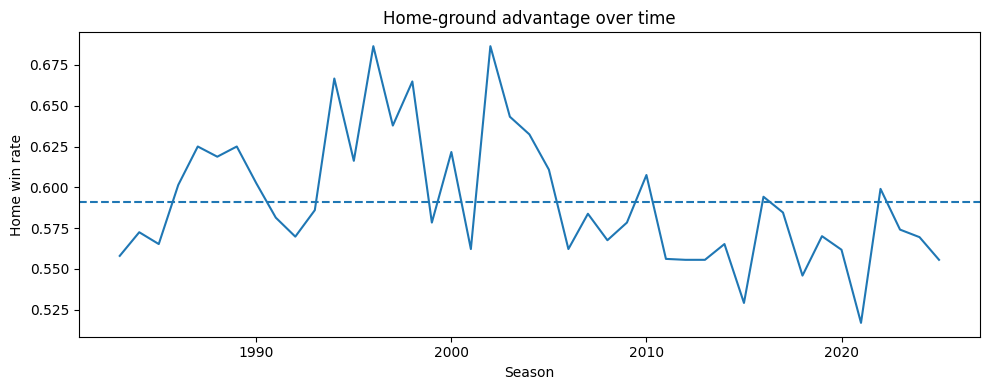

Overall home win rate: 0.591
Seasonal range: 0.517 to 0.686


In [7]:
home_by_year=home.groupby("year").home_win_binary.agg(["count","mean"])
plt.figure(figsize=(10,4)); plt.plot(home_by_year.index,home_by_year["mean"]); plt.axhline(home.home_win_binary.mean(),linestyle="--"); plt.xlabel("Season"); plt.ylabel("Home win rate"); plt.title("Home-ground advantage over time"); plt.tight_layout(); plt.show()
print("Overall home win rate:",round(home.home_win_binary.mean(),3)); print("Seasonal range:",round(home_by_year["mean"].min(),3),"to",round(home_by_year["mean"].max(),3))

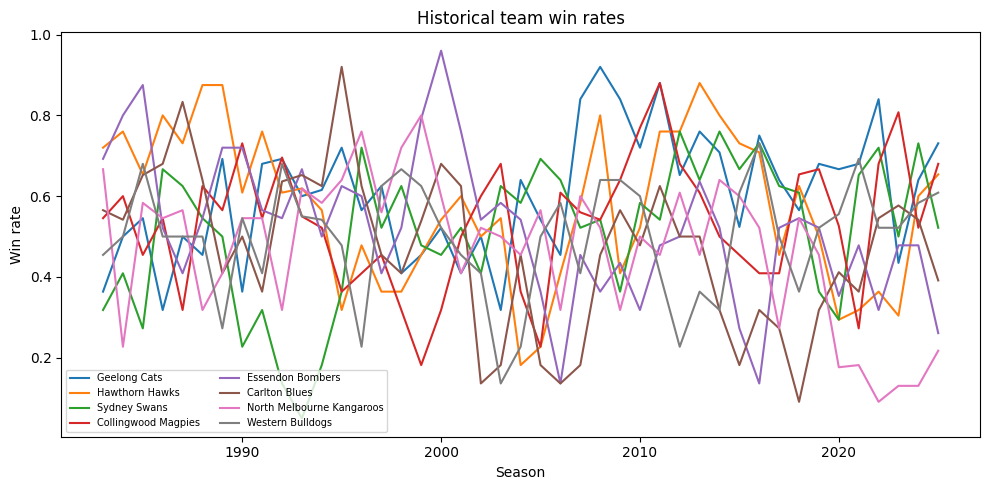

team_clean
Geelong Cats           0.611056
Hawthorn Hawks         0.582920
Collingwood Magpies    0.542169
Port Adelaide Power    0.534431
Essendon Bombers       0.529828
West Coast Eagles      0.522552
Sydney Swans           0.522044
Adelaide Crows         0.516812
Brisbane Lions         0.509601
Western Bulldogs       0.503055
Name: win, dtype: float64


In [8]:
team_hist=tm.copy(); team_hist["win"]=(team_hist.result=="W").astype(int); yt=team_hist.groupby(["year","team_clean"]).win.mean().reset_index(); top_teams=team_hist.groupby("team_clean").size().nlargest(8).index
plt.figure(figsize=(10,5))
for team in top_teams:
    q=yt[yt.team_clean==team]; plt.plot(q.year,q.win,label=team)
plt.xlabel("Season"); plt.ylabel("Win rate"); plt.title("Historical team win rates"); plt.legend(fontsize=7,ncol=2); plt.tight_layout(); plt.show()
print(team_hist.groupby("team_clean").win.mean().sort_values(ascending=False).head(10))

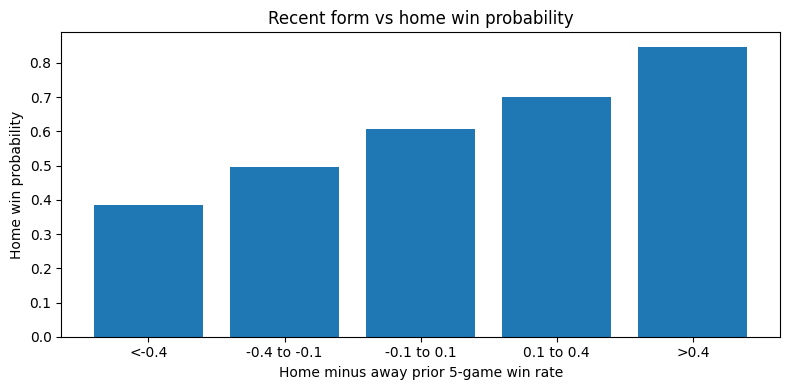

Correlation: 0.29


In [9]:
h=tm.sort_values(["team_clean","match_date","id"]).copy(); h["win"]=(h.result=="W").astype(int); h["prior_win_rate_5"]=h.groupby("team_clean").win.transform(lambda s:s.shift(1).rolling(5,min_periods=3).mean()); hh=h[h.home_away.eq("H")][["match_date","team_clean","opponent_clean","prior_win_rate_5","win"]].rename(columns={"prior_win_rate_5":"home_form_5","win":"home_win"}); aa=h[h.home_away.eq("A")][["match_date","team_clean","opponent_clean","prior_win_rate_5"]].rename(columns={"team_clean":"opponent_clean","opponent_clean":"team_clean","prior_win_rate_5":"away_form_5"}); f=hh.merge(aa,on=["match_date","team_clean","opponent_clean"],how="left"); f["form_diff"]=f.home_form_5-f.away_form_5; z=f.dropna(subset=["form_diff"]).copy(); z["bin"]=pd.cut(z.form_diff,[-1.1,-.4,-.1,.1,.4,1.1],labels=["<-0.4","-0.4 to -0.1","-0.1 to 0.1","0.1 to 0.4",">0.4"]); rates=z.groupby("bin",observed=True).home_win.mean(); plt.figure(figsize=(8,4)); plt.bar(rates.index.astype(str),rates.values); plt.xlabel("Home minus away prior 5-game win rate"); plt.ylabel("Home win probability"); plt.title("Recent form vs home win probability"); plt.tight_layout(); plt.show(); print("Correlation:",round(z[["form_diff","home_win"]].corr().iloc[0,1],3))

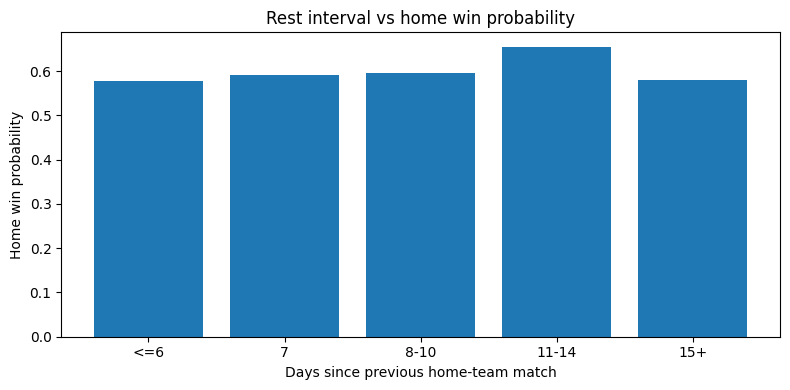

          count      mean
rest_bin                 
<=6        2129  0.578206
7          3057  0.590121
8-10       1885  0.595756
11-14       368  0.654891
15+         455  0.580220


In [10]:
h["days_rest"]=h.groupby("team_clean").match_date.diff().dt.days; rh=h[h.home_away.eq("H")].copy(); rh["rest_bin"]=pd.cut(rh.days_rest,[0,6,7,10,14,1000],labels=["<=6","7","8-10","11-14","15+"]); rr=rh.groupby("rest_bin",observed=True).win.mean(); plt.figure(figsize=(8,4)); plt.bar(rr.index.astype(str),rr.values); plt.xlabel("Days since previous home-team match"); plt.ylabel("Home win probability"); plt.title("Rest interval vs home win probability"); plt.tight_layout(); plt.show(); print(rh.groupby("rest_bin",observed=True).win.agg(["count","mean"]))

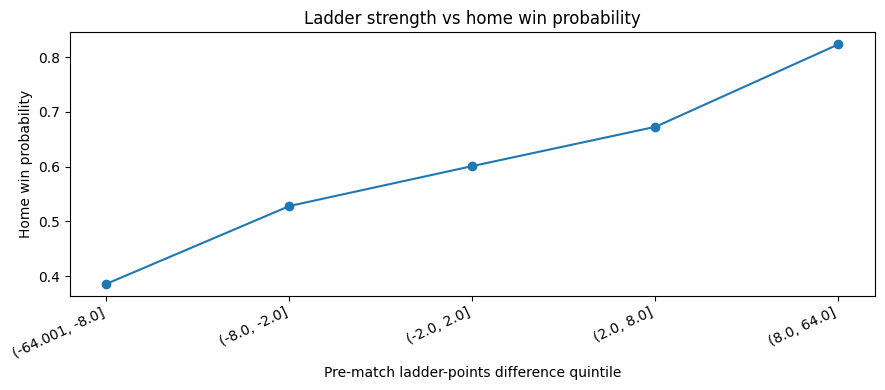

Correlation: 0.325


In [11]:
h["points"]=np.select([h.result.eq("W"),h.result.eq("D")],[4,2],default=0); h["prior_ladder_points"]=h.groupby(["team_clean","year"]).points.transform(lambda s:s.cumsum()-s); h["prior_pf"]=h.groupby(["team_clean","year"]).team_score.transform(lambda s:s.cumsum()-s); h["prior_pa"]=h.groupby(["team_clean","year"]).opponent_score.transform(lambda s:s.cumsum()-s); h["prior_ladder_pct"]=np.where(h.prior_pa>0,100*h.prior_pf/h.prior_pa,np.nan); h["prior_ladder_rank"]=h.groupby(["year","match_date"]).prior_ladder_points.rank(method="min",ascending=False)
la=h[h.home_away.eq("H")][["match_date","team_clean","opponent_clean","prior_ladder_points","prior_ladder_rank","win"]].rename(columns={"prior_ladder_points":"home_points","prior_ladder_rank":"home_rank","win":"home_win"}); aa=h[h.home_away.eq("A")][["match_date","team_clean","opponent_clean","prior_ladder_points","prior_ladder_rank"]].rename(columns={"team_clean":"opponent_clean","opponent_clean":"team_clean","prior_ladder_points":"away_points","prior_ladder_rank":"away_rank"}); ld=la.merge(aa,on=["match_date","team_clean","opponent_clean"],how="left"); ld["points_diff"]=ld.home_points-ld.away_points; q=ld.dropna(subset=["points_diff"]).copy(); q["bin"]=pd.qcut(q.points_diff,5,duplicates="drop"); pr=q.groupby("bin",observed=True).home_win.mean(); plt.figure(figsize=(9,4)); plt.plot(range(len(pr)),pr.values,marker="o"); plt.xticks(range(len(pr)),[str(x) for x in pr.index],rotation=25,ha="right"); plt.xlabel("Pre-match ladder-points difference quintile"); plt.ylabel("Home win probability"); plt.title("Ladder strength vs home win probability"); plt.tight_layout(); plt.show(); print("Correlation:",round(q[["points_diff","home_win"]].corr().iloc[0,1],3))

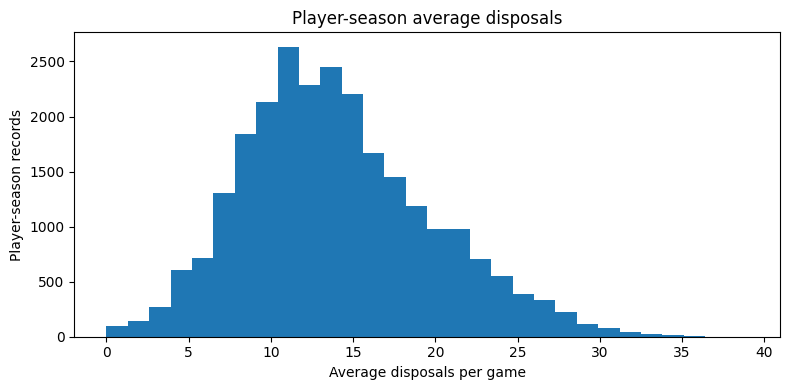

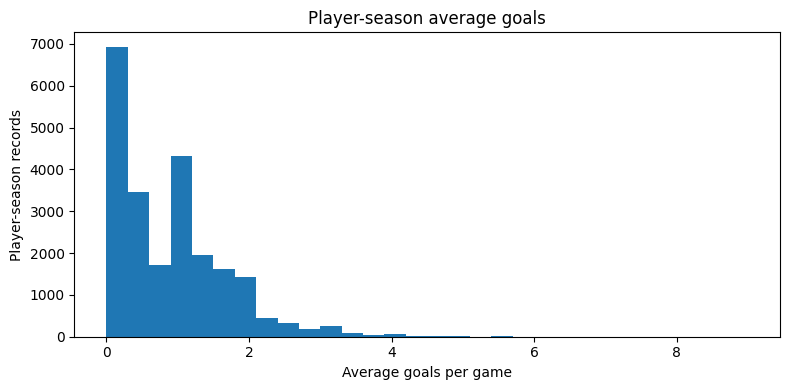

Historical disposal leaders:


,player_name,total_disposals,games
1409,Scott Pendlebury,10787.0,425
2310,Robert Harvey,9656.0,383
2,Gary Ablett,9323.0,391
2309,Brent Harvey,9213.0,432
146,Travis Boak,8976.0,387
2113,Craig Bradley,8776.0,375
1625,Joel Selwood,8746.0,355
1244,Sam Mitchell,8687.0,329
412,Patrick Dangerfield,8258.0,360
2690,Scott West,8222.0,324


Historical goal leaders:


,player_name,total_goals,games
2412,Tony Lockett,1360.0,281
585,Lance Franklin,1066.0,354
2410,Matthew Lloyd,926.0,270
2566,Matthew Richardson,800.0,282
750,Tom Hawkins,796.0,359
1519,Jack Riewoldt,787.0,347
2578,Saverio Rocca,748.0,257
2296,Barry Hall,746.0,289
255,Jeremy Cameron,736.0,280
2141,Wayne Carey,727.0,272


Position analysis unavailable: no position column.


In [12]:
season=seasonal_stats.copy(); season["pid"]=pd.to_numeric(season.player_id,errors="coerce"); info=players_info.copy(); info["pid"]=pd.to_numeric(info.id,errors="coerce"); names=info[["pid","player_name"]].drop_duplicates("pid"); ps=season.groupby("pid").agg(total_disposals=("disposals","sum"),total_goals=("goals","sum"),total_fantasy=("total_fantasy_points","sum"),games=("games_played","sum"),mean_avg_disposals=("avg_disposals","mean"),mean_avg_goals=("avg_goals","mean")).reset_index().merge(names,on="pid",how="left")
plt.figure(figsize=(8,4)); plt.hist(season.avg_disposals.dropna(),bins=30); plt.xlabel("Average disposals per game"); plt.ylabel("Player-season records"); plt.title("Player-season average disposals"); plt.tight_layout(); plt.show()
plt.figure(figsize=(8,4)); plt.hist(season.avg_goals.dropna(),bins=30); plt.xlabel("Average goals per game"); plt.ylabel("Player-season records"); plt.title("Player-season average goals"); plt.tight_layout(); plt.show()
print("Historical disposal leaders:"); display(ps.sort_values("total_disposals",ascending=False).head(10)[["player_name","total_disposals","games"]]); print("Historical goal leaders:"); display(ps.sort_values("total_goals",ascending=False).head(10)[["player_name","total_goals","games"]]); print("Position analysis unavailable: no position column.")

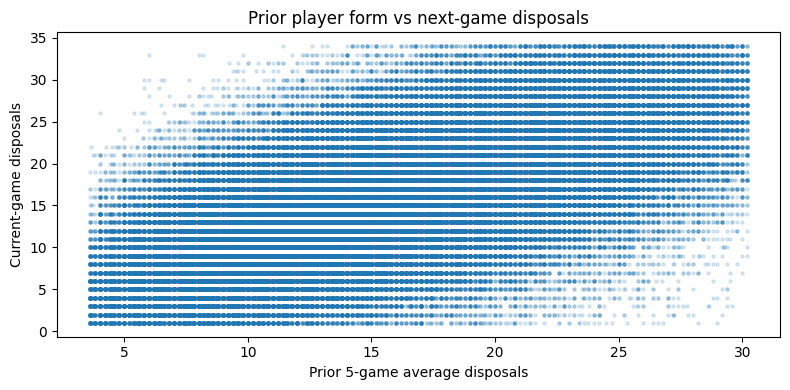

Correlation: 0.645
Weather analysis unavailable: no weather column.


In [13]:
pf=pg.dropna(subset=["prior_disposals_5","disposals"]).copy(); lo,hi=pf.prior_disposals_5.quantile([.01,.99]); pf=pf[pf.prior_disposals_5.between(lo,hi)]; lo,hi=pf.disposals.quantile([.01,.99]); pf=pf[pf.disposals.between(lo,hi)]; plt.figure(figsize=(8,4)); plt.scatter(pf.prior_disposals_5,pf.disposals,s=5,alpha=.15); plt.xlabel("Prior 5-game average disposals"); plt.ylabel("Current-game disposals"); plt.title("Prior player form vs next-game disposals"); plt.tight_layout(); plt.show(); print("Correlation:",round(pf[["prior_disposals_5","disposals"]].corr().iloc[0,1],3)); print("Weather analysis unavailable: no weather column.")

## Task 4 — Feature Engineering for Prediction

Feature version: **v1.0**. All rolling team and player features use `shift(1)` before their rolling window. Season-to-date ladder variables subtract the current match. Current-match performance is never used to construct pre-match predictors. Player-form aggregation uses current player identities but only their prior performance; a production pre-selection model should separately model player availability.

In [14]:
# Head-to-head history is calculated from canonical home rows only, preventing the current match from entering its own history.
h2h=home[["match_id","match_date","team_clean","opponent_clean","result"]].copy().sort_values(["match_date","match_id"])
h2h["pair"]=np.where(h2h.team_clean<h2h.opponent_clean,h2h.team_clean+"__"+h2h.opponent_clean,h2h.opponent_clean+"__"+h2h.team_clean)
h2h["home_h2h_win"]=h2h.result.eq("W").astype(int)
h2h["prior_h2h_games"]=h2h.groupby("pair").cumcount()
h2h["prior_h2h_home_wins"]=h2h.groupby(["pair","team_clean"])["home_h2h_win"].transform(lambda s:s.shift(1).fillna(0).cumsum())
h2h_map=h2h[["match_id","prior_h2h_games","prior_h2h_home_wins"]].rename(columns={"prior_h2h_home_wins":"home_prior_h2h_team_wins"})


In [16]:
def make_match_id(df):
    a=df.team_clean.astype(str); b=df.opponent_clean.astype(str); pair=np.where(a<b,a+"__"+b,b+"__"+a)
    return df.match_date.dt.strftime("%Y-%m-%d")+"__"+df["round"].astype(str)+"__"+pair

# Ensure 'match_id' is present in 'h' for merging later and for H2H calculations.
h["match_id"] = make_match_id(h)

# Calculate prior_score_avg_5: Rolling mean of team_score, shifted.
h["prior_score_avg_5"] = h.groupby("team_clean").team_score.transform(lambda s: s.shift(1).rolling(5, min_periods=3).mean())

# Calculate prior_margin_avg_5: Rolling mean of margin, shifted.
h["prior_margin_avg_5"] = h.groupby("team_clean").margin.transform(lambda s: s.shift(1).rolling(5, min_periods=3).mean())

# Calculate prior_win_streak: Consecutive wins before the current match.
def calculate_prior_win_streak(s):
    streaks = []
    current_streak = 0
    for val in s:
        streaks.append(current_streak) # This is the streak *before* the current game
        if val == 1: # If current game is a win
            current_streak += 1
        else: # If not a win (loss or draw)
            current_streak = 0
    return pd.Series(streaks, index=s.index)

h["prior_win_streak"] = h.groupby("team_clean").win.transform(calculate_prior_win_streak)

# Prepare team-level head-to-head statistics for merging into 'th'
# We need the number of prior games played between two teams and how many the current 'team_clean' won.
h_h2h_calcs = h.copy()
h_h2h_calcs["h2h_pair_key"] = np.where(
    h_h2h_calcs.team_clean < h_h2h_calcs.opponent_clean,
    h_h2h_calcs.team_clean + "__" + h_h2h_calcs.opponent_clean,
    h_h2h_calcs.opponent_clean + "__" + h_h2h_calcs.team_clean
)

# Sort by match_date to ensure correct cumulative calculations for prior stats
h_h2h_calcs = h_h2h_calcs.sort_values(["team_clean", "opponent_clean", "match_date"])

# Calculate prior H2H games for the specific team vs opponent pair
h_h2h_calcs["prior_h2h_games"] = h_h2h_calcs.groupby(["team_clean", "opponent_clean"]).cumcount()

# Calculate prior H2H wins for the specific team against the specific opponent, shifted
h_h2h_calcs["team_h2h_win_indicator"] = (h_h2h_calcs.result == "W").astype(int)
h_h2h_calcs["prior_h2h_team_wins"] = h_h2h_calcs.groupby(["team_clean", "opponent_clean"])[["team_h2h_win_indicator"]].transform(lambda x: x.shift(1).fillna(0).cumsum())

# Select relevant H2H columns for merging into 'h'
h_h2h_merged_cols = h_h2h_calcs[["match_id", "team_clean", "opponent_clean", "prior_h2h_games", "prior_h2h_team_wins"]]

# Merge these team-specific H2H features into 'h'
h = h.merge(h_h2h_merged_cols, on=["match_id", "team_clean", "opponent_clean"], how="left")

# Finally, define 'th' with all the calculated prior features
th = h[[ "match_id", "team_clean", "opponent_clean", "match_date",
        "prior_win_rate_5", "prior_score_avg_5", "prior_margin_avg_5", "days_rest",
        "prior_win_streak", "prior_ladder_points", "prior_ladder_pct", "prior_ladder_rank",
        "prior_h2h_games", "prior_h2h_team_wins"]].copy()


In [17]:
player_team_features=pg.groupby(["match_id","team_clean"])[["prior_disposals_5","prior_goals_5","prior_fantasy_points_5"]].agg(["mean","max"]).reset_index(); player_team_features.columns=["match_id","team_clean","team_prior_player_disposals_5_mean","team_prior_player_disposals_5_max","team_prior_player_goals_5_mean","team_prior_player_goals_5_max","team_prior_player_fantasy_5_mean","team_prior_player_fantasy_5_max"]
m=home[["match_id","year","round","match_date","team_clean","opponent_clean","venue","crowd","match_result_home","home_win_binary","margin_home"]].rename(columns={"team_clean":"home_team","opponent_clean":"away_team"})
hf=th.rename(columns={"team_clean":"home_team","prior_win_rate_5":"home_prior_win_rate_5","prior_score_avg_5":"home_prior_score_avg_5","prior_margin_avg_5":"home_prior_margin_avg_5","days_rest":"home_days_rest","prior_win_streak":"home_prior_win_streak","prior_ladder_points":"home_prior_ladder_points","prior_ladder_pct":"home_prior_ladder_pct","prior_ladder_rank":"home_prior_ladder_rank","prior_h2h_team_wins":"home_prior_h2h_team_wins","prior_h2h_games":"home_prior_h2h_games"})
af=th.rename(columns={"team_clean":"away_team","prior_win_rate_5":"away_prior_win_rate_5","prior_score_avg_5":"away_prior_score_avg_5","prior_margin_avg_5":"away_prior_margin_avg_5","days_rest":"away_days_rest","prior_win_streak":"away_prior_win_streak","prior_ladder_points":"away_prior_ladder_points","prior_ladder_pct":"away_prior_ladder_pct","prior_ladder_rank":"away_prior_ladder_rank","prior_h2h_team_wins":"away_prior_h2h_team_wins","prior_h2h_games":"away_prior_h2h_games"})
features=m.merge(hf[["home_team","match_date","home_prior_win_rate_5","home_prior_score_avg_5","home_prior_margin_avg_5","home_days_rest","home_prior_win_streak","home_prior_ladder_points","home_prior_ladder_pct","home_prior_ladder_rank","home_prior_h2h_team_wins","home_prior_h2h_games"]],on=["home_team","match_date"],how="left").merge(af[["away_team","match_date","away_prior_win_rate_5","away_prior_score_avg_5","away_prior_margin_avg_5","away_days_rest","away_prior_win_streak","away_prior_ladder_points","away_prior_ladder_pct","away_prior_ladder_rank","away_prior_h2h_team_wins","away_prior_h2h_games"]],on=["away_team","match_date"],how="left")
features["form_diff_5"]=features.home_prior_win_rate_5-features.away_prior_win_rate_5; features["score_avg_diff_5"]=features.home_prior_score_avg_5-features.away_prior_score_avg_5; features["margin_avg_diff_5"]=features.home_prior_margin_avg_5-features.away_prior_margin_avg_5; features["rest_diff"]=features.home_days_rest-features.away_days_rest; features["ladder_points_diff"]=features.home_prior_ladder_points-features.away_prior_ladder_points; features["ladder_rank_diff"]=features.away_prior_ladder_rank-features.home_prior_ladder_rank
features=features.merge(h2h_map,on="match_id",how="left")
hf2=player_team_features.rename(columns={"team_clean":"home_team","team_prior_player_disposals_5_mean":"home_player_disposals_5_mean","team_prior_player_disposals_5_max":"home_player_disposals_5_max","team_prior_player_goals_5_mean":"home_player_goals_5_mean","team_prior_player_goals_5_max":"home_player_goals_5_max","team_prior_player_fantasy_5_mean":"home_player_fantasy_5_mean","team_prior_player_fantasy_5_max":"home_player_fantasy_5_max"}); af2=player_team_features.rename(columns={"team_clean":"away_team","team_prior_player_disposals_5_mean":"away_player_disposals_5_mean","team_prior_player_disposals_5_max":"away_player_disposals_5_max","team_prior_player_goals_5_mean":"away_player_goals_5_mean","team_prior_player_goals_5_max":"away_player_goals_5_max","team_prior_player_fantasy_5_mean":"away_player_fantasy_5_mean","team_prior_player_fantasy_5_max":"away_player_fantasy_5_max"})
features=features.merge(hf2,on=["match_id","home_team"],how="left").merge(af2,on=["match_id","away_team"],how="left"); features["player_disposals_form_diff"]=features.home_player_disposals_5_mean-features.away_player_disposals_5_mean; features["player_goals_form_diff"]=features.home_player_goals_5_mean-features.away_player_goals_5_mean; features["player_fantasy_form_diff"]=features.home_player_fantasy_5_mean-features.away_player_fantasy_5_mean; features["feature_version"]="v1.0"
feature_table_v1=features.sort_values(["match_date","match_id"]).reset_index(drop=True)
feature_dictionary_v1=pd.DataFrame([
 ["form_diff_5","Home prior 5-game win rate minus away prior 5-game win rate","Previous 5 team matches; shifted","result","v1.0"],["score_avg_diff_5","Difference in prior 5-game average team score","Previous 5; shifted","team_score","v1.0"],["margin_avg_diff_5","Difference in prior 5-game average margin","Previous 5; shifted","margin","v1.0"],["rest_diff","Home days rest minus away days rest","Since previous match","match_date","v1.0"],["ladder_points_diff","Home prior points minus away prior points","Season to date; current excluded","result","v1.0"],["ladder_rank_diff","Away pre-match rank minus home rank","Pre-match standings","result, scores","v1.0"],["prior_win_streak","Consecutive prior wins","Prior matches","result","v1.0"],["prior_h2h_team_wins","Prior wins in the matchup","Earlier meetings","result, teams","v1.0"],["player form","Mean/max prior-5 player disposals, goals, fantasy","Previous player-games; shifted","player_id + stats","v1.0"]],columns=["feature","description","window","source_columns","version"])
out_dir="week3_day1_outputs"; os.makedirs(out_dir,exist_ok=True); feature_table_v1.to_csv(out_dir+"/afl_feature_table_v1.csv",index=False); feature_dictionary_v1.to_csv(out_dir+"/afl_feature_dictionary_v1.csv",index=False); print(feature_table_v1.shape); display(feature_dictionary_v1)

(7904, 55)


,feature,description,window,source_columns,version
0,form_diff_5,Home prior 5-game win rate minus away prior 5-...,Previous 5 team matches; shifted,result,v1.0
1,score_avg_diff_5,Difference in prior 5-game average team score,Previous 5; shifted,team_score,v1.0
2,margin_avg_diff_5,Difference in prior 5-game average margin,Previous 5; shifted,margin,v1.0
3,rest_diff,Home days rest minus away days rest,Since previous match,match_date,v1.0
4,ladder_points_diff,Home prior points minus away prior points,Season to date; current excluded,result,v1.0
5,ladder_rank_diff,Away pre-match rank minus home rank,Pre-match standings,"result, scores",v1.0
6,prior_win_streak,Consecutive prior wins,Prior matches,result,v1.0
7,prior_h2h_team_wins,Prior wins in the matchup,Earlier meetings,"result, teams",v1.0
8,player form,"Mean/max prior-5 player disposals, goals, fantasy",Previous player-games; shifted,player_id + stats,v1.0


### Leakage control

Rolling team and player features are shifted before aggregation. Ladder variables exclude the current match. Current-match result, score, goals, disposals and fantasy points are never used as pre-match predictors. The current roster is used only to aggregate prior player form; a production pre-selection model should separately account for availability.

In [18]:
required=["home_prior_win_rate_5","away_prior_win_rate_5","home_prior_score_avg_5","away_prior_score_avg_5","home_days_rest","away_days_rest","home_prior_ladder_points","away_prior_ladder_points"]
assert all(c in feature_table_v1.columns for c in required)
print("Leakage audit passed."); print("Saved:",out_dir+"/afl_feature_table_v1.csv")

Leakage audit passed.
Saved: week3_day1_outputs/afl_feature_table_v1.csv


## Task 5 — Reproducible Train / Hold-Out Split

The hold-out is the most recent season, 2025. A random split is inappropriate because later matches can enter training while earlier matches are used for validation, exposing the model to future information patterns. Every model this week should call the same split function.

In [19]:
def time_split(df, date_col="match_date", holdout_seasons=1):
    data=df.sort_values(date_col).copy(); years=sorted(data[date_col].dt.year.dropna().unique())
    if len(years)<=holdout_seasons: raise ValueError("Not enough seasons for requested holdout.")
    holdout_years=years[-holdout_seasons:]; train=data[~data[date_col].dt.year.isin(holdout_years)].copy(); holdout=data[data[date_col].dt.year.isin(holdout_years)].copy(); return train,holdout,holdout_years
train_df,holdout_df,held_out=time_split(feature_table_v1,holdout_seasons=1)
print("Training seasons:",train_df.match_date.dt.year.min(),"to",train_df.match_date.dt.year.max()); print("Hold-out seasons:",held_out); print("Train rows:",len(train_df)); print("Hold-out rows:",len(holdout_df))

Training seasons: 1983 to 2024
Hold-out seasons: [np.int32(2025)]
Train rows: 7688
Hold-out rows: 216


### Prediction ceiling

AFL outcomes are noisy, so strong out-of-time performance should be judged against simple baselines rather than a fixed promise of near-perfect accuracy. Injuries, selection, tactics, weather and other factors are not fully represented in these tables. Perfect or near-perfect accuracy would be suspicious because post-match statistics can leak into features. Shifted rolling features and a strict chronological hold-out are essential controls.

## Reproducibility checklist

1. Place `afl_datasets.zip` beside the notebook or upload it in Colab.
2. Run all cells from top to bottom.
3. Inspect inventory, missingness, naming variants and outliers.
4. Use `match_result_home` for the primary match-winner target.
5. Use `top_disposal_getter` and `top_goal_kicker` for player targets.
6. Use the versioned `afl_feature_table_v1.csv` for Day 2 models.
7. Use `time_split()` for every model this week.